# AnyUp3D — Experiment 2: Temporal Consistency
**Metric:** Adjacent frame cosine similarity | 2D AnyUp vs AnyUp3D  
**Dataset:** DAVIS 2017 validation set

## Cell 0 — Installs & Configuration

In [2]:
# !pip install natten --quiet

from google.colab import drive
drive.mount('/content/drive')

import os, sys
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from pathlib import Path
from PIL import Image
from sklearn.decomposition import PCA
# ── repo ──────────────────────────────────────────────────────────────────────
REPO_URL    = "https://github.com/mu-az88/anyup.git"
REPO_BRANCH = "3Dconv"
REPO_DIR    = "/content/anyup"

if not os.path.exists(REPO_DIR):
    os.system(f"git clone --branch {REPO_BRANCH} --depth 1 {REPO_URL} {REPO_DIR}")
    print(f"Cloned to {REPO_DIR}")
else:
    print(f"Repo already present at {REPO_DIR} — skipping clone.")

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")
# ── paths ─────────────────────────────────────────────────────────────────────
CKPT_ANYUP3D = "/content/drive/MyDrive/anyup3d/checkpoints/run_01/anyup3d_step10000.pth"
OUTPUT_DIR   = "/content/drive/MyDrive/anyup3d/results/exp2"
CACHE_DIR    = os.path.join(OUTPUT_DIR, "swin_cache")

# ┌──────────────────────────────────────────────────────────────────────────┐
# │  DAVIS path — set this manually if wget fails and you download it        │
# │  yourself from https://davischallenge.org → DAVIS-2017-trainval-480p.zip │
# └──────────────────────────────────────────────────────────────────────────┘
DAVIS_ROOT = "/content/DAVIS"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR,  exist_ok=True)

# ── sampling ──────────────────────────────────────────────────────────────────
DAVIS_FPS  = 24          # DAVIS 2017 native fps — do not change
TARGET_FPS = 2           # ↓ reduce to use fewer frames per clip (minimum 2 needed)
FRAME_STEP = DAVIS_FPS // TARGET_FPS   # = 12; depends on DAVIS_FPS and TARGET_FPS

# ── model / feature config ────────────────────────────────────────────────────
IMG_SIZE  = 224          # spatial input resolution; FEAT_SIZE depends on this
FEAT_DIM  = 768          # Swin-T output channels; must match AnyUp3D input_dim companion
FEAT_SIZE = 7            # = IMG_SIZE / 32; change here if IMG_SIZE changes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── TStage stub ───────────────────────────────────────────────────────────────
# Must be defined before torch.load — checkpoint embeds this object via pickle
class TStage:
    def __init__(self, t=None, start_step=None, batch_size=None):
        self.t          = t
        self.start_step = start_step
        self.batch_size = batch_size

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repo already present at /content/anyup — skipping clone.
Working directory: /content/anyup
Device: cuda


## Cell 1 — Model Loading: Video Swin-T | AnyUp3D | 2D AnyUp

In [3]:
sys.path.insert(0, "/content/anyup")
from anyup.model    import AnyUp
from anyup.model_2d import AnyUp2D  # import directly — do NOT use torch.hub.load for 2D

# ── Video Swin-T + feature hook ───────────────────────────────────────────────
_feat = {}

def _hook_fn(module, inp, out):
    # swin3d_t norm outputs (B, T, H, W, C) — permute to (B, C, T, H, W)
    _feat['norm'] = out.detach().permute(0, 4, 1, 2, 3).contiguous()

swin = torchvision.models.video.swin3d_t(weights="KINETICS400_V1").to(device).eval()
swin.norm.register_forward_hook(_hook_fn)
print("Video Swin-T loaded")

# ── AnyUp3D ───────────────────────────────────────────────────────────────────
model_3d = AnyUp(
    input_dim       = 3,
    qk_dim          = 128,
    kernel_size     = 1,
    kernel_size_lfu = 5,    # critical — omitting causes 73 missing keys
    window_ratio    = 0.1,
    num_heads       = 4,
    t_k             = 1,
).to(device).eval()

ckpt    = torch.load(CKPT_ANYUP3D, map_location="cpu", weights_only=False)  # weights_only=False required for TStage
sd      = ckpt["anyup"]   # key is "anyup" — not "model" or "state_dict"
missing, unexpected = model_3d.load_state_dict(sd, strict=True)
print(f"AnyUp3D loaded | missing={missing} | unexpected={unexpected}")

# ── 2D AnyUp ─────────────────────────────────────────────────────────────────
model_2d = AnyUp2D().to(device).eval()
sd_2d    = torch.hub.load_state_dict_from_url(
    "https://github.com/wimmerth/anyup/releases/download/checkpoint/anyup_paper.pth",
    map_location=device,
)
model_2d.load_state_dict(sd_2d)
print("AnyUp2D loaded")

Video Swin-T loaded
AnyUp3D loaded | missing=[] | unexpected=[]
AnyUp2D loaded


## Cell 2 — DAVIS 2017 Download & Clip Loader

> **Manual fallback:** If `wget` fails below:
> 1. Download `DAVIS-2017-trainval-480p.zip` from [davischallenge.org](https://davischallenge.org)
> 2. Upload to Drive or directly to `/content/`
> 3. Set `DAVIS_ROOT` in Cell 0 to the extracted folder path
> 4. Skip this cell and go to Cell 3

In [4]:
# ── CELL 2 ───────────────────────────────────────────────────────────────────
# DAVIS 2017 evaluation package + dataset extraction

# ── evaluation package (also needed for Exp 3 J&F scoring) ───────────────────
if not os.path.exists("/content/davis2017-evaluation"):
    subprocess.run([
        "git", "clone",
        "https://github.com/davisvideochallenge/davis2017-evaluation.git",
        "/content/davis2017-evaluation"
    ], check=True)
    subprocess.run(
        ["python", "setup.py", "install"],
        cwd="/content/davis2017-evaluation", check=True
    )
    print("DAVIS evaluation package installed")
else:
    print("DAVIS evaluation package already present")

# ── dataset extraction ────────────────────────────────────────────────────────
DAVIS_ZIP = "/content/drive/MyDrive/anyup3d/DAVIS-2017-trainval-480p.zip"

if not os.path.exists(os.path.join(DAVIS_ROOT, "ImageSets")):
    print("Extracting DAVIS from Drive...")
    subprocess.run(["unzip", "-q", DAVIS_ZIP, "-d", "/content/"], check=True)
    print("Done.")
else:
    print(f"DAVIS already present at {DAVIS_ROOT}")

# ── clip loader ───────────────────────────────────────────────────────────────
def load_clip_paths(davis_root, split="val"):
    val_txt    = Path(davis_root) / "ImageSets" / "2017" / f"{split}.txt"
    clip_names = [l.strip() for l in val_txt.read_text().splitlines() if l.strip()]

    clips = {}
    for name in clip_names:
        frame_dir  = Path(davis_root) / "JPEGImages" / "480p" / name
        all_frames = sorted(frame_dir.glob("*.jpg"))
        sampled    = all_frames[::FRAME_STEP]   # 2fps; step set by FRAME_STEP in Cell 0
        if len(sampled) < 2:
            print(f"  skip {name} — only {len(sampled)} sampled frame(s)")
            continue
        clips[name] = [str(p) for p in sampled]

    print(f"\nLoaded {len(clips)} clips")
    for name, paths in clips.items():
        print(f"  {name}: T={len(paths)}")
    return clips

if os.path.exists(os.path.join(DAVIS_ROOT, "ImageSets")):
    clips = load_clip_paths(DAVIS_ROOT)
else:
    print("DAVIS not found — check DAVIS_ZIP path and re-run this cell.")
    clips = {}

DAVIS evaluation package already present
DAVIS already present at /content/DAVIS

Loaded 30 clips
  bike-packing: T=6
  blackswan: T=5
  bmx-trees: T=7
  breakdance: T=7
  camel: T=8
  car-roundabout: T=7
  car-shadow: T=4
  cows: T=9
  dance-twirl: T=8
  dog: T=5
  dogs-jump: T=6
  drift-chicane: T=5
  drift-straight: T=5
  goat: T=8
  gold-fish: T=7
  horsejump-high: T=5
  india: T=7
  judo: T=3
  kite-surf: T=5
  lab-coat: T=4
  libby: T=5
  loading: T=5
  mbike-trick: T=7
  motocross-jump: T=4
  paragliding-launch: T=7
  parkour: T=9
  pigs: T=7
  scooter-black: T=4
  shooting: T=4
  soapbox: T=9


## Cell 3 — Swin Feature Precomputation → Cache per Clip
Run once; subsequent runs skip already-cached clips.

In [5]:
preprocess = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def extract_swin_features(frame_paths):
    """
    Returns:
        feats  : (T, FEAT_DIM, FEAT_SIZE, FEAT_SIZE)  float32
        guides : (T, 3, IMG_SIZE, IMG_SIZE)            float32
    T varies per clip depending on clip length and FRAME_STEP.
    """
    feats, guides = [], []
    for path in frame_paths:
        img   = Image.open(path).convert("RGB")
        frame = preprocess(img)                                           # (3, 224, 224)
        guides.append(frame)

        # Swin requires T>=2 — duplicate the single frame along the time axis
        inp = frame.unsqueeze(0).unsqueeze(2).expand(-1, -1, 2, -1, -1).to(device)  # (1, 3, 2, 224, 224)
        with torch.no_grad():
            swin(inp)
        # hook output: (1, 768, 1, 7, 7) → squeeze B and T → (768, 7, 7)
        feat = _feat['norm'].squeeze(0).squeeze(1).cpu()
        feats.append(feat)

    return torch.stack(feats, dim=0), torch.stack(guides, dim=0)  # (T,768,7,7), (T,3,224,224)

for clip_name, frame_paths in clips.items():
    cache_path = os.path.join(CACHE_DIR, f"{clip_name}.pt")
    if os.path.exists(cache_path):
        print(f"  skip {clip_name} (cached)")
        continue
    feats, guides = extract_swin_features(frame_paths)
    torch.save({"feats": feats, "guides": guides}, cache_path)
    print(f"  {clip_name}: T={feats.shape[0]}, feats={tuple(feats.shape)}")

print("\nPrecomputation complete.")

  skip bike-packing (cached)
  skip blackswan (cached)
  skip bmx-trees (cached)
  skip breakdance (cached)
  skip camel (cached)
  skip car-roundabout (cached)
  skip car-shadow (cached)
  skip cows (cached)
  skip dance-twirl (cached)
  skip dog (cached)
  skip dogs-jump (cached)
  skip drift-chicane (cached)
  skip drift-straight (cached)
  skip goat (cached)
  skip gold-fish (cached)
  skip horsejump-high (cached)
  skip india (cached)
  skip judo (cached)
  skip kite-surf (cached)
  skip lab-coat (cached)
  skip libby (cached)
  skip loading (cached)
  skip mbike-trick (cached)
  skip motocross-jump (cached)
  skip paragliding-launch (cached)
  skip parkour (cached)
  skip pigs (cached)
  skip scooter-black (cached)
  skip shooting (cached)
  skip soapbox (cached)

Precomputation complete.


## Cell 4 — AnyUp3D Full-Volume Inference (all T frames at once)

In [6]:
def run_anyup3d(feats, guides):
    """
    feats  : (T, FEAT_DIM, FEAT_SIZE, FEAT_SIZE)
    guides : (T, 3, IMG_SIZE, IMG_SIZE)
    Returns: (T, FEAT_DIM, IMG_SIZE, IMG_SIZE)
    """
    # rearrange to (1, C, T, H, W) for the model
    feat_vol  = feats.permute(1, 0, 2, 3).unsqueeze(0).to(device)    # (1, 768, T, 7, 7)
    guide_vol = guides.permute(1, 0, 2, 3).unsqueeze(0).to(device)   # (1, 3, T, 224, 224)
    with torch.no_grad():
        out = model_3d(guide_vol, feat_vol)                           # (1, 768, T, 224, 224)
    return out.squeeze(0).permute(1, 0, 2, 3).cpu()                  # (T, 768, 224, 224)

results_3d = {}
for clip_name in clips:
    out_path = os.path.join(CACHE_DIR, f"{clip_name}_3d.pt")
    if os.path.exists(out_path):
        print(f"  skip {clip_name} (cached)")
        continue
    cache_path = os.path.join(CACHE_DIR, f"{clip_name}.pt")
    data = torch.load(cache_path, map_location="cpu")
    out  = run_anyup3d(data["feats"], data["guides"])
    torch.save(out, out_path)
    print(f"  {clip_name}: out={tuple(out.shape)}")
    del data, out
    torch.cuda.empty_cache()

print("\nAnyUp3D inference complete.")

  bike-packing: out=(6, 768, 224, 224)
  blackswan: out=(5, 768, 224, 224)
  bmx-trees: out=(7, 768, 224, 224)
  breakdance: out=(7, 768, 224, 224)
  camel: out=(8, 768, 224, 224)
  car-roundabout: out=(7, 768, 224, 224)
  car-shadow: out=(4, 768, 224, 224)
  cows: out=(9, 768, 224, 224)
  dance-twirl: out=(8, 768, 224, 224)
  dog: out=(5, 768, 224, 224)
  dogs-jump: out=(6, 768, 224, 224)
  drift-chicane: out=(5, 768, 224, 224)
  drift-straight: out=(5, 768, 224, 224)
  goat: out=(8, 768, 224, 224)
  gold-fish: out=(7, 768, 224, 224)
  horsejump-high: out=(5, 768, 224, 224)
  india: out=(7, 768, 224, 224)
  judo: out=(3, 768, 224, 224)
  kite-surf: out=(5, 768, 224, 224)
  lab-coat: out=(4, 768, 224, 224)
  libby: out=(5, 768, 224, 224)
  loading: out=(5, 768, 224, 224)
  mbike-trick: out=(7, 768, 224, 224)
  motocross-jump: out=(4, 768, 224, 224)
  paragliding-launch: out=(7, 768, 224, 224)
  parkour: out=(9, 768, 224, 224)
  pigs: out=(7, 768, 224, 224)
  scooter-black: out=(4, 768,

## Cell 5 — 2D AnyUp Frame-by-Frame Inference (no temporal context)

In [7]:
def run_anyup2d(feats, guides):
    """
    feats  : (T, FEAT_DIM, FEAT_SIZE, FEAT_SIZE)
    guides : (T, 3, IMG_SIZE, IMG_SIZE)
    Returns: (T, FEAT_DIM, IMG_SIZE, IMG_SIZE)
    """
    results = []
    for t in range(feats.shape[0]):   # iterate over T frames; T varies per clip
        feat_t  = feats[t].unsqueeze(0).to(device)    # (1, 768, 7, 7)
        guide_t = guides[t].unsqueeze(0).to(device)   # (1, 3, 224, 224)
        with torch.no_grad():
            out_t = model_2d(guide_t, feat_t)          # (1, 768, 224, 224)
        results.append(out_t.squeeze(0).cpu())         # (768, 224, 224)
    return torch.stack(results, dim=0)                 # (T, 768, 224, 224)

results_2d = {}
for clip_name in clips:
    out_path = os.path.join(CACHE_DIR, f"{clip_name}_2d.pt")
    if os.path.exists(out_path):
        print(f"  skip {clip_name} (cached)")
        continue
    cache_path = os.path.join(CACHE_DIR, f"{clip_name}.pt")
    data = torch.load(cache_path, map_location="cpu")
    out  = run_anyup2d(data["feats"], data["guides"])
    torch.save(out, out_path)
    print(f"  {clip_name}: out={tuple(out.shape)}")
    del data, out
    torch.cuda.empty_cache()

print("\n2D AnyUp inference complete.")

  bike-packing: out=(6, 768, 224, 224)
  blackswan: out=(5, 768, 224, 224)
  bmx-trees: out=(7, 768, 224, 224)
  breakdance: out=(7, 768, 224, 224)
  camel: out=(8, 768, 224, 224)
  car-roundabout: out=(7, 768, 224, 224)
  car-shadow: out=(4, 768, 224, 224)
  cows: out=(9, 768, 224, 224)
  dance-twirl: out=(8, 768, 224, 224)
  dog: out=(5, 768, 224, 224)
  dogs-jump: out=(6, 768, 224, 224)
  drift-chicane: out=(5, 768, 224, 224)
  drift-straight: out=(5, 768, 224, 224)
  goat: out=(8, 768, 224, 224)
  gold-fish: out=(7, 768, 224, 224)
  horsejump-high: out=(5, 768, 224, 224)
  india: out=(7, 768, 224, 224)
  judo: out=(3, 768, 224, 224)
  kite-surf: out=(5, 768, 224, 224)
  lab-coat: out=(4, 768, 224, 224)
  libby: out=(5, 768, 224, 224)
  loading: out=(5, 768, 224, 224)
  mbike-trick: out=(7, 768, 224, 224)
  motocross-jump: out=(4, 768, 224, 224)
  paragliding-launch: out=(7, 768, 224, 224)
  parkour: out=(9, 768, 224, 224)
  pigs: out=(7, 768, 224, 224)
  scooter-black: out=(4, 768,

## Cell 6 — Adjacent Frame Cosine Similarity → Results Table & Save

In [8]:
def adjacent_cosine_sim(feats):
    """
    feats: (T, C, H, W)
    Returns mean cosine similarity across all adjacent pairs and spatial positions.
    """
    feats_norm = F.normalize(feats, dim=1)                      # (T, C, H, W)
    sim        = (feats_norm[:-1] * feats_norm[1:]).sum(dim=1)  # (T-1, H, W)
    return sim.mean().item()

rows = []
for clip_name in clips:
    f2 = torch.load(os.path.join(CACHE_DIR, f"{clip_name}_2d.pt"), map_location="cpu")
    f3 = torch.load(os.path.join(CACHE_DIR, f"{clip_name}_3d.pt"), map_location="cpu")
    sim_2d = adjacent_cosine_sim(f2)
    sim_3d = adjacent_cosine_sim(f3)
    rows.append((clip_name, sim_2d, sim_3d))
    del f2, f3

# ── print table ───────────────────────────────────────────────────────────────
col_w   = max(len(n) for n, *_ in rows) + 2
header  = f"{'Clip':<{col_w}} {'2D AnyUp':>12} {'AnyUp3D':>12} {'Δ':>10}"
divider = "─" * len(header)
print(header)
print(divider)

sims_2d, sims_3d = [], []
for clip_name, s2, s3 in rows:
    print(f"{clip_name:<{col_w}} {s2:>12.4f} {s3:>12.4f} {s3-s2:>+10.4f}")
    sims_2d.append(s2)
    sims_3d.append(s3)

print(divider)
m2, std2 = np.mean(sims_2d), np.std(sims_2d)
m3, std3 = np.mean(sims_3d), np.std(sims_3d)
print(f"{'Mean ± Std':<{col_w}} {m2:.4f}±{std2:.4f} {m3:.4f}±{std3:.4f} {m3-m2:>+10.4f}")

# ── save ─────────────────────────────────────────────────────────────────────
result_path = os.path.join(OUTPUT_DIR, "temporal_cosine_sim.txt")
with open(result_path, "w") as f:
    f.write(header + "\n" + divider + "\n")
    for clip_name, s2, s3 in rows:
        f.write(f"{clip_name:<{col_w}} {s2:>12.4f} {s3:>12.4f} {s3-s2:>+10.4f}\n")
    f.write(f"\n{'Mean':<{col_w}} {m2:.4f}±{std2:.4f} {m3:.4f}±{std3:.4f} {m3-m2:>+10.4f}\n")

print(f"\nSaved → {result_path}")

Clip                     2D AnyUp      AnyUp3D          Δ
─────────────────────────────────────────────────────────
bike-packing               0.6012       0.8758    +0.2746
blackswan                  0.7589       0.8819    +0.1230
bmx-trees                  0.4180       0.7635    +0.3456
breakdance                 0.6301       0.8896    +0.2595
camel                      0.7133       0.8513    +0.1380
car-roundabout             0.6592       0.7542    +0.0951
car-shadow                 0.6484       0.7750    +0.1266
cows                       0.7231       0.7593    +0.0363
dance-twirl                0.5049       0.6864    +0.1815
dog                        0.5276       0.6689    +0.1413
dogs-jump                  0.6175       0.8977    +0.2803
drift-chicane              0.8187       0.9329    +0.1141
drift-straight             0.3239       0.5865    +0.2625
goat                       0.6606       0.6613    +0.0007
gold-fish                  0.8260       0.8984    +0.0724
horsejump-high

## Cell 7 — PCA Visualization: 2D AnyUp row vs AnyUp3D row across T frames

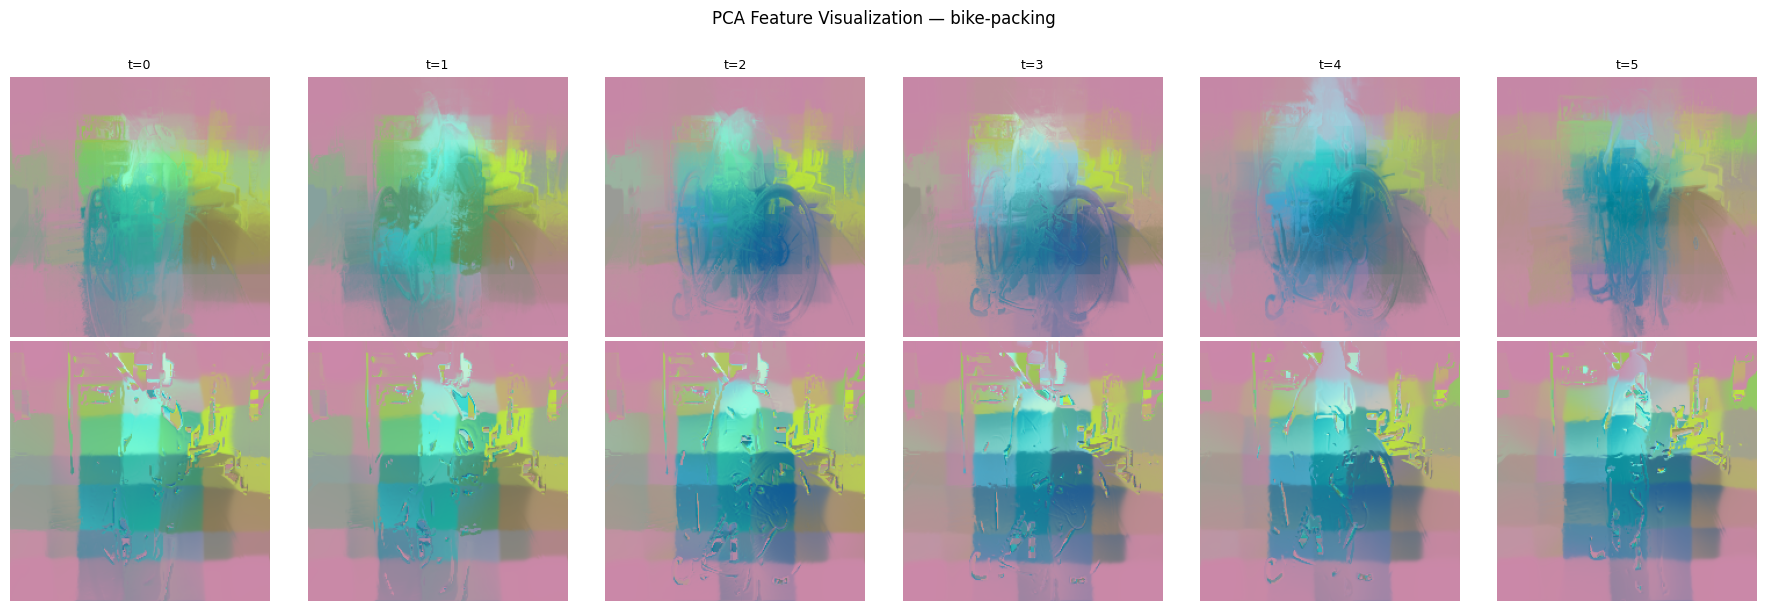

Saved → /content/drive/MyDrive/anyup3d/results/exp2/pca_bike-packing.png


In [9]:
# ── CELL 7 ───────────────────────────────────────────────────────────────────
# PCA visualization: 2D AnyUp row vs AnyUp3D row across T frames

# ← change to any clip name from the table above
VIZ_CLIP   = list(clips.keys())[0]

PCA_SAMPLE = 50_000   # max tokens used to FIT PCA; ↓ reduce if slow or OOM
                      # does not affect which frames are visualized, only fitting speed

f2 = torch.load(os.path.join(CACHE_DIR, f"{VIZ_CLIP}_2d.pt"), map_location="cpu")  # (T, 768, 224, 224)
f3 = torch.load(os.path.join(CACHE_DIR, f"{VIZ_CLIP}_3d.pt"), map_location="cpu")  # (T, 768, 224, 224)
T  = f2.shape[0]

def feats_to_pca_rgb(feats_2d, feats_3d):
    """
    feats_2d, feats_3d : (T, C, H, W)
    Fits PCA jointly so both rows share the same color space.
    Returns pca_2d, pca_3d each of shape (T, H, W, 3) in [0, 1].
    """
    T, C, H, W = feats_2d.shape

    all_flat = np.concatenate([
        feats_2d.permute(0, 2, 3, 1).reshape(-1, C).numpy(),   # (T*H*W, C)
        feats_3d.permute(0, 2, 3, 1).reshape(-1, C).numpy(),
    ], axis=0)                                                   # (2*T*H*W, C)

    # subsample for fitting — applying is done on full set
    idx = np.random.choice(len(all_flat), min(PCA_SAMPLE, len(all_flat)), replace=False)
    pca = PCA(n_components=3)
    pca.fit(all_flat[idx])

    def apply_pca(feats):
        flat = feats.permute(0, 2, 3, 1).reshape(-1, C).numpy()
        proj = pca.transform(flat)                               # (T*H*W, 3)
        proj = (proj - proj.min()) / (proj.max() - proj.min() + 1e-8)
        return proj.reshape(T, H, W, 3)

    return apply_pca(feats_2d), apply_pca(feats_3d)

pca_2d, pca_3d = feats_to_pca_rgb(f2, f3)
del f2, f3

fig, axes = plt.subplots(2, T, figsize=(3 * T, 6))   # cols = T frames; T varies per clip

row_labels = ["2D AnyUp\n(frame-by-frame)", "AnyUp3D\n(full volume)"]
for row_idx, (pca_imgs, label) in enumerate(zip([pca_2d, pca_3d], row_labels)):
    for t in range(T):
        ax = axes[row_idx, t]
        ax.imshow(pca_imgs[t])
        ax.axis("off")
        if t == 0:
            ax.set_ylabel(label, fontsize=10, labelpad=6)
        if row_idx == 0:
            ax.set_title(f"t={t}", fontsize=9)

fig.suptitle(f"PCA Feature Visualization — {VIZ_CLIP}", fontsize=12, y=1.01)
plt.tight_layout()

viz_path = os.path.join(OUTPUT_DIR, f"pca_{VIZ_CLIP}.png")
plt.savefig(viz_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {viz_path}")